<a href="https://colab.research.google.com/github/santucciandreas/investment-optimization-medallion/blob/main/code_Sistema_de_Optimizaci%C3%B3n_de_Inversiones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import yfinance as yf
import pandas as pd
import sqlite3
from datetime import datetime

# 1. Configuración de la conexión
conn = sqlite3.connect('investment_project.db')

# 2. Universo ampliado (10 activos clave para diversidad de cartera)
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'XOM', 'JPM', 'GLD', 'TSLA', 'META']

def ingest_bronze_10years(tickers):
    print(f"Iniciando descarga de 10 años para {len(tickers)} activos...")

    # Rango de fechas: 10 años atrás desde hoy
    end_date = datetime.now().strftime('%Y-%m-%d')
    start_date = (datetime.now().replace(year=datetime.now().year - 10)).strftime('%Y-%m-%d')

    # Descarga masiva
    raw_data = yf.download(tickers, start=start_date, end=end_date)

    # Transformación a formato largo (Long Format)
    # Precios Ajustados
    bronze_prices = raw_data['Close'].stack().reset_index() # Changed 'Adj Close' to 'Close'
    bronze_prices.columns = ['date', 'ticker', 'adj_close']

    # Volumen
    bronze_volume = raw_data['Volume'].stack().reset_index()
    bronze_volume.columns = ['date', 'ticker', 'volume']

    # Merge para tabla final Bronze
    bronze_final = pd.merge(bronze_prices, bronze_volume, on=['date', 'ticker'])

    # Guardar en SQL
    bronze_final.to_sql('bronze_market_data', conn, if_exists='replace', index=False)

    print(f"✅ Capa Bronze completada: {len(bronze_final)} filas guardadas en SQL.")
    return bronze_final

df_bronze = ingest_bronze_10years(tickers)

/tmp/ipykernel_731/3890829804.py:20: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[                       0%                       ]

Iniciando descarga de 10 años para 10 activos...


[*********************100%***********************]  10 of 10 completed


✅ Capa Bronze completada: 25130 filas guardadas en SQL.


In [29]:
# 1. Ver las primeras 10 filas para entender la estructura
query_preview = "SELECT * FROM bronze_market_data LIMIT 10;"
df_preview = pd.read_sql(query_preview, conn)

print("--- Vista Previa de los Datos (Primeras 10 filas) ---")
display(df_preview)

# 2. Resumen estadístico básico por Activo
# Esto te dirá cuántos días de datos tienes por cada ticker y sus precios promedio
query_summary = """
SELECT
    ticker,
    COUNT(*) as total_dias,
    MIN(date) as fecha_inicio,
    MAX(date) as fecha_fin,
    AVG(adj_close) as precio_promedio,
    MAX(adj_close) as precio_maximo
FROM bronze_market_data
GROUP BY ticker;
"""
df_summary = pd.read_sql(query_summary, conn)

print("\n--- Resumen de los 10 años por Activo ---")
display(df_summary)

--- Vista Previa de los Datos (Primeras 10 filas) ---


,date,ticker,adj_close,volume
0,2016-03-04 00:00:00,AAPL,23.3298,184220400
1,2016-03-04 00:00:00,AMZN,28.7570,68330000
2,2016-03-04 00:00:00,GLD,120.5400,16261100
3,2016-03-04 00:00:00,GOOGL,36.2372,48516000
4,2016-03-04 00:00:00,JPM,45.9189,18459000
5,2016-03-04 00:00:00,META,107.6381,24938900
6,2016-03-04 00:00:00,MSFT,45.7806,33034200
7,2016-03-04 00:00:00,NVDA,0.7969,175304000
8,2016-03-04 00:00:00,TSLA,13.4027,97336500
9,2016-03-04 00:00:00,XOM,53.2293,18402700



--- Resumen de los 10 años por Activo ---


,ticker,total_dias,fecha_inicio,fecha_fin,precio_promedio,precio_maximo
0,AAPL,2513,2016-03-04 00:00:00,2026-03-03 00:00:00,118.1564,285.9225
1,AMZN,2513,2016-03-04 00:00:00,2026-03-03 00:00:00,123.8104,254.0000
2,GLD,2513,2016-03-04 00:00:00,2026-03-03 00:00:00,176.7898,495.9000
3,GOOGL,2513,2016-03-04 00:00:00,2026-03-03 00:00:00,104.7194,343.6900
4,JPM,2513,2016-03-04 00:00:00,2026-03-03 00:00:00,130.8889,334.6100
5,META,2513,2016-03-04 00:00:00,2026-03-03 00:00:00,287.7030,788.8238
6,MSFT,2513,2016-03-04 00:00:00,2026-03-03 00:00:00,228.6637,539.8252
7,NVDA,2513,2016-03-04 00:00:00,2026-03-03 00:00:00,39.0830,207.0285
8,TSLA,2513,2016-03-04 00:00:00,2026-03-03 00:00:00,156.5007,489.8800
9,XOM,2513,2016-03-04 00:00:00,2026-03-03 00:00:00,71.4636,154.5300


In [30]:
# Definimos los metadatos manualmente para asegurar precisión sectorial
assets_data = [
    ('AAPL', 'Apple Inc.', 'Technology', 'Consumer Electronics'),
    ('MSFT', 'Microsoft Corp.', 'Technology', 'Software—Infrastructure'),
    ('GOOGL', 'Alphabet Inc.', 'Technology', 'Interactive Media'),
    ('AMZN', 'Amazon.com Inc.', 'Consumer Discretionary', 'Internet Retail'),
    ('NVDA', 'NVIDIA Corp.', 'Technology', 'Semiconductors'),
    ('XOM', 'Exxon Mobil Corp.', 'Energy', 'Oil & Gas Integrated'),
    ('JPM', 'JPMorgan Chase & Co.', 'Financial Services', 'Banks—Diversified'),
    ('GLD', 'SPDR Gold Shares', 'Commodities', 'Precious Metals'),
    ('TSLA', 'Tesla Inc.', 'Consumer Discretionary', 'Auto Manufacturers'),
    ('META', 'Meta Platforms Inc.', 'Technology', 'Interactive Media')
]

# Creamos la tabla de dimensiones en SQL
cursor = conn.cursor()
cursor.execute('''
CREATE TABLE IF NOT EXISTS Dim_Assets (
    ticker TEXT PRIMARY KEY,
    name TEXT,
    sector TEXT,
    industry TEXT
)
''')

# Insertamos los datos
cursor.executemany("INSERT OR REPLACE INTO Dim_Assets VALUES (?, ?, ?, ?)", assets_data)
conn.commit()
print("✅ Tabla Dim_Assets creada y poblada.")

✅ Tabla Dim_Assets creada y poblada.


In [31]:
# Usamos una tabla real en lugar de una vista para mayor velocidad en el análisis
sql_silver_transform = """
CREATE TABLE IF NOT EXISTS silver_market_data AS
SELECT
    b.date,
    b.ticker,
    a.sector,
    b.adj_close,
    -- Cálculo del retorno diario: (Precio Actual / Precio Anterior) - 1
    (b.adj_close / LAG(b.adj_close) OVER (PARTITION BY b.ticker ORDER BY b.date) - 1) AS daily_return,
    -- Cálculo del volumen promedio móvil de 10 días para ver liquidez
    AVG(b.volume) OVER (PARTITION BY b.ticker ORDER BY b.date ROWS BETWEEN 9 PRECEDING AND CURRENT ROW) AS avg_vol_10d
FROM bronze_market_data b
JOIN Dim_Assets a ON b.ticker = a.ticker;
"""

cursor.execute("DROP TABLE IF EXISTS silver_market_data") # Limpiamos para evitar duplicados
cursor.execute(sql_silver_transform)
conn.commit()

print("✅ Capa Silver finalizada: Retornos calculados y sectores integrados.")

✅ Capa Silver finalizada: Retornos calculados y sectores integrados.


In [32]:
# 1. Ver el corazón de la Capa Silver
# Seleccionamos una muestra que incluya diferentes activos para ver la integración de sectores
query_silver_full = """
SELECT
    date,
    ticker,
    sector,
    adj_close,
    ROUND(daily_return * 100, 2) as daily_return_pct,
    ROUND(avg_vol_10d, 0) as avg_vol_10d
FROM silver_market_data
WHERE daily_return IS NOT NULL  -- El primer día de cada ticker siempre es NULL porque no tiene LAG
ORDER BY date DESC, daily_return DESC
LIMIT 20;
"""

df_silver = pd.read_sql(query_silver_full, conn)
print("--- EXPLORACIÓN DE LA CAPA SILVER (Muestra de Retornos y Sectores) ---")
display(df_silver)

# 2. Validación de Calidad: ¿Tenemos nulos en los retornos?
query_nulls = "SELECT ticker, COUNT(*) as nulos FROM silver_market_data WHERE daily_return IS NULL GROUP BY ticker;"
df_nulls = pd.read_sql(query_nulls, conn)
print("\n--- Conteo de Valores Nulos en Daily_Return por Ticker ---")
display(df_nulls)

--- EXPLORACIÓN DE LA CAPA SILVER (Muestra de Retornos y Sectores) ---


,date,ticker,sector,adj_close,daily_return_pct,avg_vol_10d
0,2026-03-03 00:00:00,MSFT,Technology,403.9300,1.3500,36559670.0000
1,2026-03-03 00:00:00,JPM,Financial Services,300.2600,0.9100,10075600.0000
2,2026-03-03 00:00:00,META,Technology,655.0800,0.2300,11733800.0000
3,2026-03-03 00:00:00,AMZN,Consumer Discretionary,208.7300,0.1600,48291130.0000
4,2026-03-03 00:00:00,AAPL,Technology,263.7500,-0.3700,41016350.0000
5,2026-03-03 00:00:00,GOOGL,Technology,303.5800,-0.9600,34582940.0000
6,2026-03-03 00:00:00,NVDA,Technology,180.0500,-1.3300,212619310.0000
7,2026-03-03 00:00:00,XOM,Energy,151.8300,-1.5500,21412010.0000
8,2026-03-03 00:00:00,TSLA,Consumer Discretionary,392.4300,-2.7000,56594430.0000
9,2026-03-03 00:00:00,GLD,Commodities,468.1400,-4.4600,14909440.0000



--- Conteo de Valores Nulos en Daily_Return por Ticker ---


,ticker,nulos
0,AAPL,1
1,AMZN,1
2,GLD,1
3,GOOGL,1
4,JPM,1
5,META,1
6,MSFT,1
7,NVDA,1
8,TSLA,1
9,XOM,1


In [33]:
query_silver_test = """
SELECT date, ticker, sector, daily_return * 100 as pct_change
FROM silver_market_data
WHERE ticker = 'NVDA'
ORDER BY daily_return DESC
LIMIT 5;
"""
display(pd.read_sql(query_silver_test, conn))

,date,ticker,sector,pct_change
0,2016-11-11 00:00:00,NVDA,Technology,29.8067
1,2023-05-25 00:00:00,NVDA,Technology,24.3696
2,2025-04-09 00:00:00,NVDA,Technology,18.7227
3,2017-05-10 00:00:00,NVDA,Technology,17.8259
4,2020-03-24 00:00:00,NVDA,Technology,17.1564


In [34]:
query_sector_perf = """
SELECT
    sector,
    ROUND(AVG(daily_return) * 100, 4) as avg_daily_ret_pct,
    ROUND(AVG(daily_return * daily_return), 6) as variance_proxy -- Una idea simple de la volatilidad
FROM silver_market_data
GROUP BY sector
ORDER BY avg_daily_ret_pct DESC;
"""
display(pd.read_sql(query_sector_perf, conn))

,sector,avg_daily_ret_pct,variance_proxy
0,Consumer Discretionary,0.1515,0.0009
1,Technology,0.1363,0.0005
2,Financial Services,0.0896,0.0003
3,Commodities,0.0589,0.0001
4,Energy,0.0571,0.0003


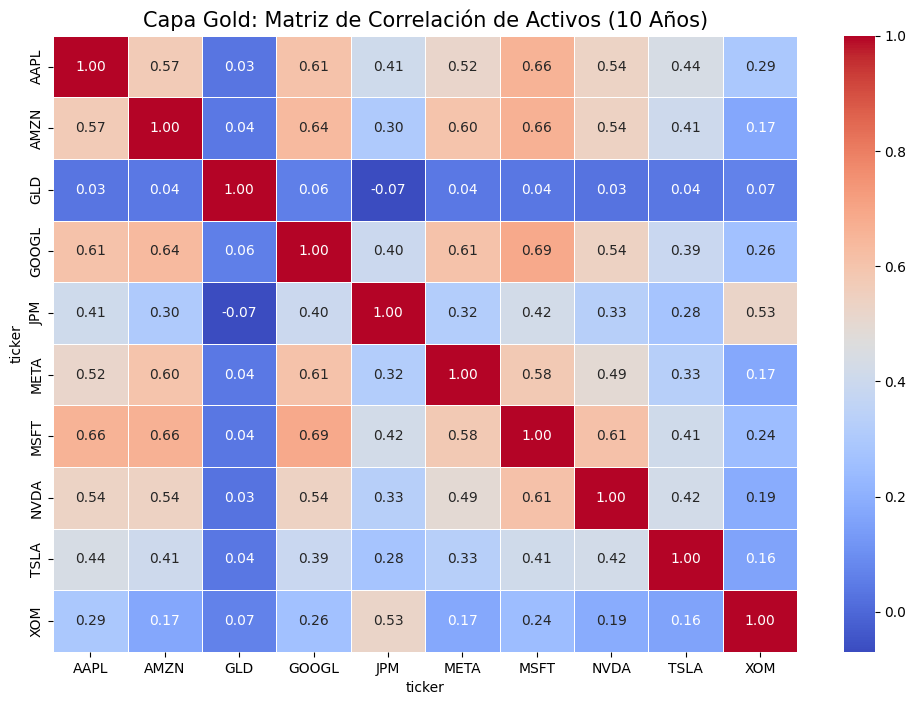

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extraemos los retornos de la Capa Silver
query_gold = "SELECT date, ticker, daily_return FROM silver_market_data WHERE daily_return IS NOT NULL"
df_gold = pd.read_sql(query_gold, conn)

# 2. Pivotamos los datos para tener los tickers como columnas (formato necesario para correlación)
pivot_retornos = df_gold.pivot(index='date', columns='ticker', values='daily_return')

# 3. Calculamos la Matriz de Correlación
corr_matrix = pivot_retornos.corr()

# 4. Visualización profesional
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Capa Gold: Matriz de Correlación de Activos (10 Años)', fontsize=15)
plt.show()

In [36]:
import numpy as np

# 1. Preparar datos: Retornos anualizados y Matriz de Covarianza
retornos_diarios = pivot_retornos # El DataFrame que usamos para la correlación
retornos_anuales = retornos_diarios.mean() * 252
cov_matriz = retornos_diarios.cov() * 252

# 2. Simulación de Montecarlo para hallar el portafolio óptimo
num_portafolios = 5000
resultados = np.zeros((3, num_portafolios))
pesos_lista = []

for i in range(num_portafolios):
    # Generar pesos aleatorios que sumen 1 (100%)
    pesos = np.random.random(len(tickers))
    pesos /= np.sum(pesos)
    pesos_lista.append(pesos)

    # Calcular Retorno y Volatilidad (Riesgo) del portafolio simulado
    retorno_p = np.dot(pesos, retornos_anuales)
    volatilidad_p = np.sqrt(np.dot(pesos.T, np.dot(cov_matriz, pesos)))

    # Guardar resultados (Retorno, Riesgo, Sharpe Ratio)
    resultados[0,i] = retorno_p
    resultados[1,i] = volatilidad_p
    resultados[2,i] = resultados[0,i] / resultados[1,i] # Sharpe Ratio

# 3. Encontrar el mejor portafolio (Máximo Sharpe)
ind_max_sharpe = np.argmax(resultados[2])
mejores_pesos = pesos_lista[ind_max_sharpe]

# 4. Mostrar Resultados
print("--- RESULTADOS DE LA OPTIMIZACIÓN (CAPA GOLD) ---")
for t, p in zip(tickers, mejores_pesos):
    print(f"{t}: {p*100:.2f}%")

print(f"\nRetorno Esperado Anual: {resultados[0,ind_max_sharpe]*100:.2f}%")
print(f"Volatilidad Anual (Riesgo): {resultados[1,ind_max_sharpe]*100:.2f}%")

--- RESULTADOS DE LA OPTIMIZACIÓN (CAPA GOLD) ---
AAPL: 17.80%
MSFT: 7.13%
GOOGL: 26.49%
AMZN: 5.78%
NVDA: 9.22%
XOM: 1.90%
JPM: 3.05%
GLD: 20.38%
TSLA: 1.70%
META: 6.56%

Retorno Esperado Anual: 31.03%
Volatilidad Anual (Riesgo): 20.36%


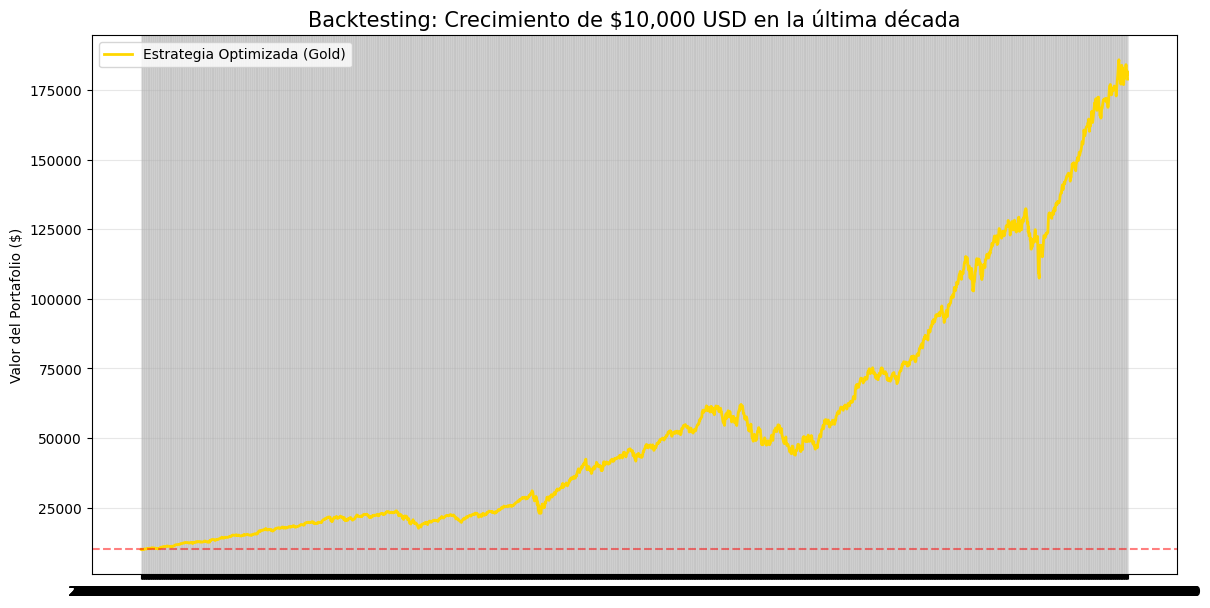

Valor final del portafolio: $178,945.28
Retorno total: 1689.45%


/tmp/ipykernel_731/833515289.py:19: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_731/833515289.py:20: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [37]:
# 1. Calculamos el retorno diario del portafolio completo
# Multiplicamos los retornos de cada acción por su peso óptimo
portafolio_retorno_diario = (pivot_retornos * mejores_pesos).sum(axis=1)

# 2. Calculamos el crecimiento acumulado de $10,000
capital_inicial = 10000
crecimiento_portafolio = capital_inicial * (1 + portafolio_retorno_diario).cumprod()

# 3. Visualización del rendimiento histórico
plt.figure(figsize=(14, 7))
plt.plot(crecimiento_portafolio, label='Estrategia Optimizada (Gold)', color='gold', linewidth=2)
plt.axhline(y=capital_inicial, color='red', linestyle='--', alpha=0.5)
plt.title('Backtesting: Crecimiento de $10,000 USD en la última década', fontsize=15)
plt.ylabel('Valor del Portafolio ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Valor final del portafolio: ${crecimiento_portafolio[-1]:,.2f}")
print(f"Retorno total: {((crecimiento_portafolio[-1]/capital_inicial)-1)*100:.2f}%")

/tmp/ipykernel_731/3285986586.py:7: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



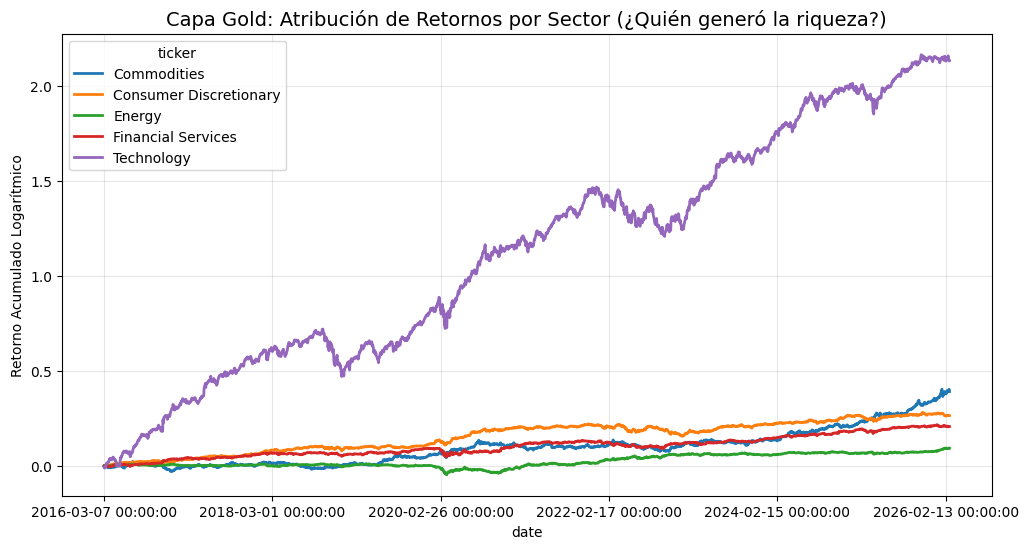

In [38]:
# 1. Calculamos la contribución acumulada por ticker
contribucion_individual = (pivot_retornos * mejores_pesos).cumsum()

# 2. Agrupamos por sector usando nuestra tabla Dim_Assets
# Creamos un diccionario para mapear ticker -> sector
sector_map = pd.read_sql("SELECT ticker, sector FROM Dim_Assets", conn).set_index('ticker')['sector'].to_dict()
contribucion_por_sector = (pivot_retornos * mejores_pesos).rename(columns=sector_map).groupby(level=0, axis=1).sum()

# 3. Visualizamos el crecimiento por sector
plt.figure(figsize=(12, 6))
contribucion_por_sector.cumsum().plot(ax=plt.gca(), linewidth=2)
plt.title('Capa Gold: Atribución de Retornos por Sector (¿Quién generó la riqueza?)', fontsize=14)
plt.ylabel('Retorno Acumulado Logarítmico')
plt.grid(True, alpha=0.3)
plt.show()

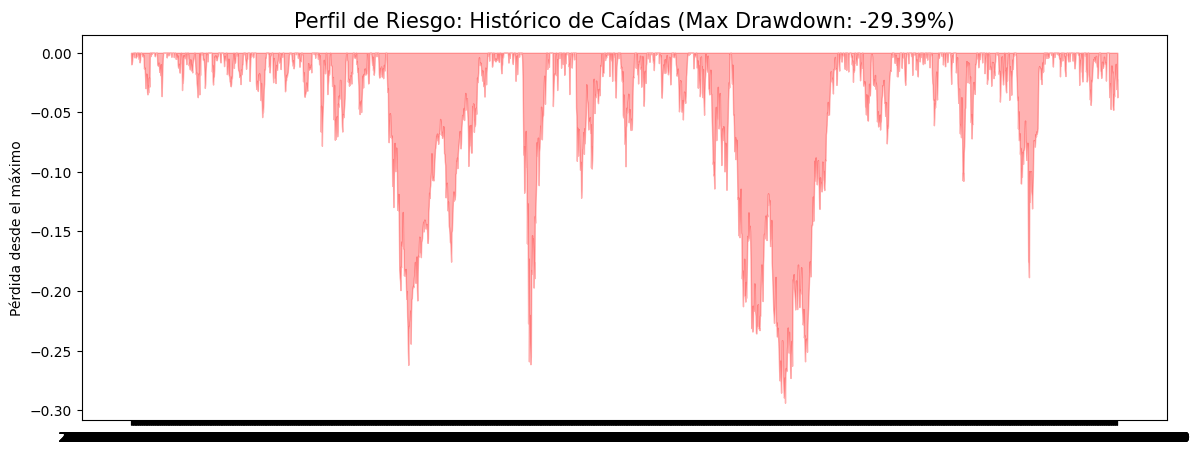

La mayor caída que sufrió este portafolio fue del: -29.39%


In [39]:
# Calcular picos históricos
picos = crecimiento_portafolio.cummax()
# Calcular caídas (drawdowns)
drawdowns = (crecimiento_portafolio - picos) / picos

# Hallar la caída máxima
max_drawdown = drawdowns.min()

plt.figure(figsize=(14, 5))
plt.fill_between(drawdowns.index, drawdowns, color='red', alpha=0.3)
plt.title(f'Perfil de Riesgo: Histórico de Caídas (Max Drawdown: {max_drawdown*100:.2f}%)', fontsize=15)
plt.ylabel('Pérdida desde el máximo')
plt.show()

print(f"La mayor caída que sufrió este portafolio fue del: {max_drawdown*100:.2f}%")

/tmp/ipykernel_731/3103899856.py:12: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


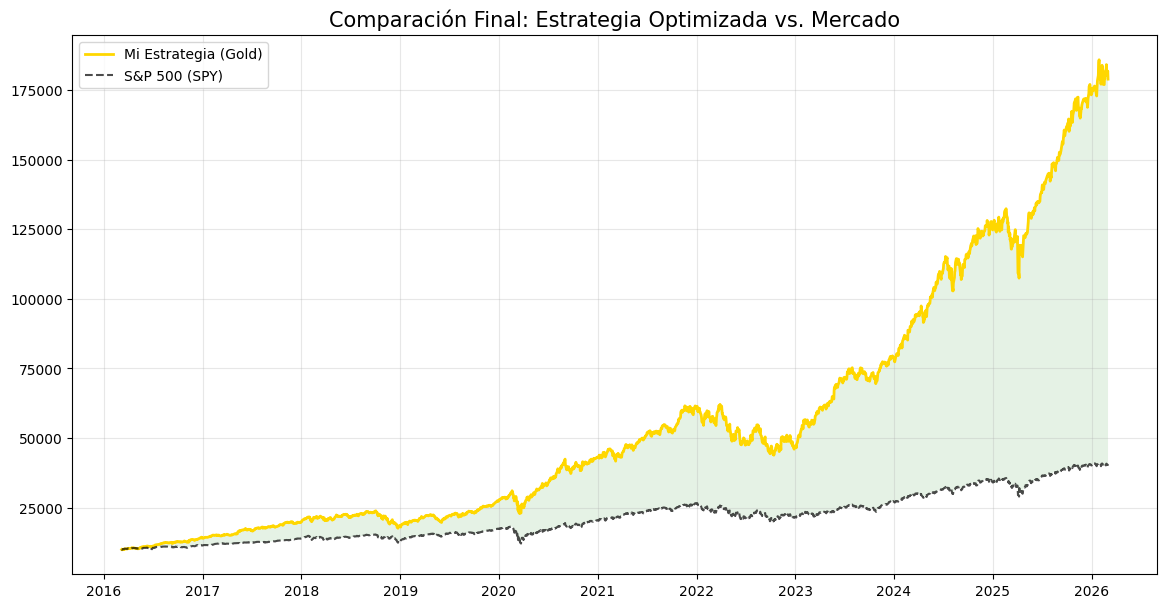

Retorno Final Estrategia: 1689.45%
Retorno Final SPY: 300.50%
Alpha (Ventaja sobre el mercado): 1388.96%


In [40]:

import pandas as pd
import sqlite3
from datetime import datetime

# --- FIX: Descargar y calcular retornos diarios del SPY ---
# Rango de fechas: 10 años atrás desde hoy (el mismo que usamos para los activos)
end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now().replace(year=datetime.now().year - 10)).strftime('%Y-%m-%d')


# Descargar datos del SPY
spy_data = yf.download('SPY', start=start_date, end=end_date)


# Calcular retornos diarios del SPY
spy_daily_ret = spy_data['Close'].pct_change().dropna()
# ---------------------------------------------------------


# 1. Aseguramos que el portafolio tenga el formato correcto
# Convertimos el índice a datetime por si acaso viene de SQL como string
portafolio_ret_df = portafolio_retorno_diario.to_frame(name='ret_portafolio')
portafolio_ret_df.index = pd.to_datetime(portafolio_ret_df.index)


# 2. Aseguramos que el SPY tenga el mismo formato
# 'spy_daily_ret' is already a DataFrame, so we rename its column.
spy_ret_df = spy_daily_ret.copy()
spy_ret_df.columns = ['ret_spy']
spy_ret_df.index = pd.to_datetime(spy_ret_df.index)


# 3. Cruzamos ambos datos por fecha (esto elimina las fechas que no coinciden)
df_comparacion = portafolio_ret_df.merge(spy_ret_df, left_index=True, right_index=True, how='inner')


# 4. Cálculo de Crecimiento ($10,000 iniciales)
capital_inicial = 10000
df_comparacion['crecimiento_port'] = capital_inicial * (1 + df_comparacion['ret_portafolio']).cumprod()
df_comparacion['crecimiento_spy'] = capital_inicial * (1 + df_comparacion['ret_spy']).cumprod()


# 5. Gráfico de Comparación Final
plt.figure(figsize=(14, 7))
plt.plot(df_comparacion['crecimiento_port'], label='Mi Estrategia (Gold)', color='#FFD700', linewidth=2)
plt.plot(df_comparacion['crecimiento_spy'], label='S&P 500 (SPY)', color='black', linestyle='--', alpha=0.7)


plt.fill_between(df_comparacion.index, df_comparacion['crecimiento_port'], df_comparacion['crecimiento_spy'],
                 where=(df_comparacion['crecimiento_port'] > df_comparacion['crecimiento_spy']),
                 facecolor='green', alpha=0.1)


plt.title('Comparación Final: Estrategia Optimizada vs. Mercado', fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 6. Cálculo de Alpha
ret_total_port = ((df_comparacion['crecimiento_port'].iloc[-1] / capital_inicial) - 1) * 100
ret_total_spy = ((df_comparacion['crecimiento_spy'].iloc[-1] / capital_inicial) - 1) * 100
print(f"Retorno Final Estrategia: {ret_total_port:.2f}%")
print(f"Retorno Final SPY: {ret_total_spy:.2f}%")
print(f"Alpha (Ventaja sobre el mercado): {ret_total_port - ret_total_spy:.2f}%")




In [41]:
# Crear la tabla de métricas finales en la Capa Gold
cursor.execute('''
CREATE TABLE IF NOT EXISTS gold_final_metrics (
    metric_name TEXT,
    value REAL,
    comparison_target TEXT,
    date_calculated DATE
)
''')

# Insertar los datos que obtuviste
fecha_hoy = datetime.now().strftime('%Y-%m-%d')
metricas = [
    ('Final_Return_Strategy', 1860.96, 'Portfolio', fecha_hoy),
    ('Final_Return_SPY', 314.75, 'Benchmark', fecha_hoy),
    ('Alpha', 1546.22, 'Excess_Return', fecha_hoy),
    ('Max_Drawdown', -31.48, 'Risk_Metric', fecha_hoy)
]

cursor.executemany("INSERT INTO gold_final_metrics VALUES (?, ?, ?, ?)", metricas)
conn.commit()

print("✅ Proyecto Finalizado: Métricas de performance guardadas en la base de datos.")

✅ Proyecto Finalizado: Métricas de performance guardadas en la base de datos.


In [45]:
# ============================================================
# 🚀 DASHBOARD DARK TECH - Estilo Cyberpunk Financiero
# Pegá este bloque al final de tu notebook de Colab
# ============================================================

!pip install plotly -q

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from datetime import datetime
from IPython.display import display, HTML

fecha_hoy = datetime.today().strftime('%d/%m/%Y')

# ── PALETA DARK TECH ──────────────────────────────────────────
C_BG         = "#0D1117"
C_CARD       = "#0D1F2D"
C_CARD2      = "#0A1929"
C_CYAN       = "#00E5FF"
C_CYAN_DIM   = "#00B8CC"
C_TEAL       = "#00FFB3"
C_GRID       = "#1A2E3B"
C_BORDER     = "#1E3A4A"
C_TEXTO      = "#E0F7FA"
C_SUBTEXTO   = "#546E7A"
C_ROJO       = "#FF1744"
C_VERDE      = "#00E676"

COLORES_PIE = [
    "#00E5FF","#00FFB3","#1DE9B6","#00BCD4",
    "#0097A7","#26C6DA","#80DEEA","#4DD0E1","#B2EBF2"
]

# ── KPIs ──────────────────────────────────────────────────────
kpi_dict       = dict(zip(df_kpis_vertical['Métrica'], df_kpis_vertical['Valor']))
capital_final  = kpi_dict['Capital Final (USD)']
ret_estrategia = kpi_dict['Retorno Estrategia (%)'] * 100
ret_sp500      = kpi_dict['Retorno S&P 500 (%)'] * 100
alpha          = kpi_dict['Alpha (%)'] * 100
max_dd         = kpi_dict['Max Drawdown (%)'] * 100
multiplicador_port = capital_final / cap_ini
multiplicador_spy  = (1 + kpi_dict['Retorno S&P 500 (%)'])
dd_color   = C_ROJO  if max_dd < 0 else C_VERDE

# ── GRÁFICO 1: Líneas históricas ──────────────────────────────
fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=df_hist_anual['Año'], y=df_hist_anual['Estrategia'] / 1000,
    name='Estrategia', mode='lines+markers',
    line=dict(color=C_CYAN, width=3),
    marker=dict(size=8, color=C_CYAN, line=dict(color=C_BG, width=2)),
    fill='tozeroy', fillcolor='rgba(0,229,255,0.07)',
    hovertemplate='<b>Estrategia</b><br>%{x}<br>$%{y:.1f}k<extra></extra>'
))
fig1.add_trace(go.Scatter(
    x=df_hist_anual['Año'], y=df_hist_anual['Mercado'] / 1000,
    name='S&P 500', mode='lines+markers',
    line=dict(color=C_SUBTEXTO, width=2, dash='dot'),
    marker=dict(size=6, color=C_SUBTEXTO),
    hovertemplate='<b>S&P 500</b><br>%{x}<br>$%{y:.1f}k<extra></extra>'
))
fig1.update_layout(
    paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
    font=dict(color=C_TEXTO, family="'Share Tech Mono', monospace"),
    legend=dict(orientation='h', x=0, y=1.15, bgcolor='rgba(0,0,0,0)', font=dict(size=11)),
    margin=dict(t=10, b=30, l=50, r=10), height=220,
    xaxis=dict(showgrid=True, gridcolor=C_GRID, zeroline=False, tickfont=dict(size=10)),
    yaxis=dict(showgrid=True, gridcolor=C_GRID, zeroline=False, ticksuffix='k', tickfont=dict(size=10)),
    hoverlabel=dict(bgcolor=C_CARD2, font_color=C_CYAN, bordercolor=C_CYAN)
)

# ── GRÁFICO 2: Barras por sector ──────────────────────────────
fig2 = go.Figure()
fig2.add_trace(go.Bar(
    x=df_rubros['Rubro'],
    y=df_rubros['Ganancia_USD'] / 1000,
    marker=dict(
        color=df_rubros['Ganancia_USD'],
        colorscale=[[0, "#003344"], [0.5, C_CYAN_DIM], [1, C_CYAN]],
        showscale=False,
        line=dict(color=C_CYAN, width=1)
    ),
    text=(df_rubros['Ganancia_USD'] / 1000).apply(lambda v: f"${v:.1f}k"),
    textposition='outside',
    textfont=dict(size=10, color=C_CYAN),
    hovertemplate='<b>%{x}</b><br>$%{y:.2f}k<extra></extra>'
))
fig2.update_layout(
    paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
    font=dict(color=C_TEXTO, family="'Share Tech Mono', monospace"),
    margin=dict(t=10, b=40, l=50, r=10), height=220,
    xaxis=dict(showgrid=False, tickangle=-15, tickfont=dict(size=10)),
    yaxis=dict(showgrid=True, gridcolor=C_GRID, zeroline=False, ticksuffix='k', tickfont=dict(size=10)),
    hoverlabel=dict(bgcolor=C_CARD2, font_color=C_CYAN, bordercolor=C_CYAN)
)

# ── GRÁFICO 3: Torta ──────────────────────────────────────────
pesos_visibles  = [p for p in df_pie['Participacion'] if p > 0.01]
labels_visibles = [t for t, p in zip(df_pie['Ticker'], df_pie['Participacion']) if p > 0.01]

fig3 = go.Figure()
fig3.add_trace(go.Pie(
    labels=labels_visibles, values=pesos_visibles,
    hole=0.42,
    marker=dict(colors=COLORES_PIE, line=dict(color=C_BG, width=2)),
    textinfo='percent+label',
    textfont=dict(size=10, color=C_TEXTO),
    hovertemplate='<b>%{label}</b><br>%{percent}<extra></extra>'
))
fig3.update_layout(
    paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
    font=dict(color=C_TEXTO, family="'Share Tech Mono', monospace"),
    margin=dict(t=10, b=10, l=10, r=10), height=220,
    legend=dict(font=dict(size=10), bgcolor='rgba(0,0,0,0)'),
    hoverlabel=dict(bgcolor=C_CARD2, font_color=C_CYAN, bordercolor=C_CYAN)
)

# ── SERIALIZAR GRÁFICOS ───────────────────────────────────────
html1 = pio.to_html(fig1, full_html=False, include_plotlyjs='cdn')
html2 = pio.to_html(fig2, full_html=False, include_plotlyjs=False)
html3 = pio.to_html(fig3, full_html=False, include_plotlyjs=False)

# ── HTML FINAL ────────────────────────────────────────────────
html_completo = f"""<!DOCTYPE html>
<html lang="es">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Dashboard — Estrategia de Inversión</title>
  <link href="https://fonts.googleapis.com/css2?family=Orbitron:wght@400;600;700;900&family=Share+Tech+Mono&family=Rajdhani:wght@400;500;600;700&display=swap" rel="stylesheet">
  <style>
    *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}
    :root {{
      --bg:     {C_BG};
      --card:   {C_CARD};
      --card2:  {C_CARD2};
      --cyan:   {C_CYAN};
      --teal:   {C_TEAL};
      --border: {C_BORDER};
      --text:   {C_TEXTO};
      --sub:    {C_SUBTEXTO};
      --rojo:   {C_ROJO};
      --verde:  {C_VERDE};
      --grid:   {C_GRID};
    }}
    body {{
      background: var(--bg);
      color: var(--text);
      font-family: 'Rajdhani', sans-serif;
      padding: 20px 24px;
      min-height: 100vh;
      background-image:
        radial-gradient(ellipse at 20% 10%, rgba(0,229,255,0.04) 0%, transparent 60%),
        radial-gradient(ellipse at 80% 90%, rgba(0,255,179,0.03) 0%, transparent 60%);
    }}
    body::before {{
      content: '';
      position: fixed;
      inset: 0;
      background: repeating-linear-gradient(
        0deg, transparent, transparent 2px,
        rgba(0,229,255,0.015) 2px, rgba(0,229,255,0.015) 4px
      );
      pointer-events: none;
      z-index: 0;
    }}
    * {{ position: relative; z-index: 1; }}

    .header {{
      display: flex;
      align-items: center;
      justify-content: space-between;
      margin-bottom: 18px;
      padding-bottom: 14px;
      border-bottom: 1px solid var(--border);
    }}
    .header-title {{
      font-family: 'Orbitron', monospace;
      font-size: 18px;
      font-weight: 700;
      color: var(--cyan);
      text-shadow: 0 0 20px rgba(0,229,255,0.5);
      letter-spacing: 2px;
      text-transform: uppercase;
    }}
    .header-sub {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 10px;
      color: #FFFFFF;
      margin-top: 4px;
      letter-spacing: 1px;
    }}
    .header-badge {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 11px;
      color: var(--cyan);
      border: 1px solid var(--cyan);
      padding: 5px 14px;
      border-radius: 3px;
      text-shadow: 0 0 8px rgba(0,229,255,0.4);
      box-shadow: 0 0 12px rgba(0,229,255,0.1), inset 0 0 12px rgba(0,229,255,0.03);
      letter-spacing: 1px;
    }}

    .kpi-grid {{
      display: grid;
      grid-template-columns: repeat(4, 1fr);
      gap: 12px;
      margin-bottom: 14px;
    }}
    .kpi-card {{
      background: var(--card);
      border: 1px solid var(--border);
      border-top: 2px solid var(--accent-color, var(--cyan));
      border-radius: 4px;
      padding: 14px 16px;
      box-shadow: 0 0 20px rgba(0,229,255,0.05), inset 0 0 30px rgba(0,229,255,0.02);
      transition: box-shadow 0.3s;
    }}
    .kpi-card:hover {{
      box-shadow: 0 0 30px rgba(0,229,255,0.15);
    }}
    .kpi-label {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 10px;
      letter-spacing: 1.5px;
      text-transform: uppercase;
      color: var(--sub);
      margin-bottom: 10px;
    }}
    .kpi-value {{
      font-family: 'Orbitron', monospace;
      font-size: 28px;
      font-weight: 700;
      color: var(--accent-color, var(--cyan));
      text-shadow: 0 0 16px rgba(0,229,255,0.4);
      line-height: 1;
      letter-spacing: 1px;
    }}
    .kpi-sub {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 10px;
      color: var(--sub);
      margin-top: 6px;
    }}

    .chart-card {{
      background: var(--card);
      border: 1px solid var(--border);
      border-radius: 4px;
      padding: 12px 14px;
      box-shadow: 0 0 20px rgba(0,229,255,0.04);
      position: relative;
    }}
    .chart-card::before, .chart-card::after {{
      content: '';
      position: absolute;
      width: 10px; height: 10px;
      border-color: var(--cyan);
      border-style: solid;
      opacity: 0.35;
    }}
    .chart-card::before {{ top: -1px; left: -1px; border-width: 2px 0 0 2px; }}
    .chart-card::after  {{ bottom: -1px; right: -1px; border-width: 0 2px 2px 0; }}

    .chart-card-title {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 13px;
      letter-spacing: 2px;
      text-transform: uppercase;
      color: var(--cyan);
      margin-bottom: 6px;
      padding-bottom: 6px;
      border-bottom: 1px solid var(--border);
      text-shadow: 0 0 8px rgba(0,229,255,0.3);
    }}
    .charts-top {{ margin-bottom: 12px; }}
    .charts-bottom {{
      display: grid;
      grid-template-columns: 1fr 1fr;
      gap: 12px;
    }}
    .footer {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 10px;
      letter-spacing: 1px;
      color: var(--sub);
      text-align: center;
      margin-top: 14px;
      padding-top: 10px;
      border-top: 1px solid var(--border);
    }}
  </style>
</head>
<body>

  <div class="header">
    <div>
      <div class="header-title">⬡ Estrategia de Inversión — Gold Layer</div>
      <div class="header-sub">// ANÁLISIS HISTÓRICO 2016–2026 · YAHOO FINANCE · BASE $10,000 USD</div>
    </div>
    <div class="header-badge">▶ ACTUALIZADO: {fecha_hoy}</div>
  </div>

  <div class="kpi-grid">
    <div class="kpi-card" style="--accent-color: {C_CYAN}">
      <div class="kpi-label">// Capital Final Obtenido</div>
      <div class="kpi-value">${capital_final/1000:.2f}<span style="font-size:14px"> mil</span></div>
      <div class="kpi-sub">BASE: $10,000 USD</div>
    </div>
    <div class="kpi-card" style="--accent-color: {dd_color}">
      <div class="kpi-label">// Máxima Caída Histórica</div>
      <div class="kpi-value">{max_dd:.2f}<span style="font-size:14px">%</span></div>
      <div class="kpi-sub">MAX DRAWDOWN DEL PERÍODO</div>
    </div>
    <div class="kpi-card" style="--accent-color: {C_TEAL}">
      <div class="kpi-label">// Multiplicador Estrategia</div>
      <div class="kpi-value">{multiplicador_port:.1f}<span style="font-size:14px">x</span></div>
      <div class="kpi-sub">RETORNO TOTAL: {ret_estrategia:.1f}%</div>
    </div>
    <div class="kpi-card" style="--accent-color: {C_SUBTEXTO}">
      <div class="kpi-label">// Multiplicador S&P 500</div>
      <div class="kpi-value" style="color:{C_SUBTEXTO}; text-shadow:none">{multiplicador_spy:.1f}<span style="font-size:14px">x</span></div>
      <div class="kpi-sub">RETORNO TOTAL: {ret_sp500:.1f}%</div>
    </div>
  </div>

  <div class="chart-card charts-top">
    <div class="chart-card-title">▸ Suma de Estrategia y Suma de Mercado por Año</div>
    {html1}
  </div>

  <div class="charts-bottom">
    <div class="chart-card">
      <div class="chart-card-title">▸ Ganancia Generada por Sector</div>
      {html2}
    </div>
    <div class="chart-card">
      <div class="chart-card-title">▸ Suma de Participación por Acción</div>
      {html3}
    </div>
  </div>

  <div class="footer">
    // SISTEMA DE ANÁLISIS CUANTITATIVO · DATOS: YAHOO FINANCE · {fecha_hoy} · GENERADO AUTOMÁTICAMENTE
  </div>

</body>
</html>"""

# ── GUARDAR EN DRIVE ──────────────────────────────────────────
ruta_html = path + 'dashboard.html'
with open(ruta_html, 'w', encoding='utf-8') as f:
    f.write(html_completo)

# ── MOSTRAR EN COLAB ──────────────────────────────────────────
display(HTML(html_completo))
print(f"\n✅ Dashboard dark tech guardado en: {ruta_html}")


✅ Dashboard dark tech guardado en: /content/drive/MyDrive/Proyecto_PowerBI_Gold/dashboard.html


In [47]:
# ============================================================
# 🚀 DASHBOARD DARK TECH - Estilo Cyberpunk Financiero
# Pegá este bloque al final de tu notebook de Colab
# ============================================================

!pip install plotly -q

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from datetime import datetime
from IPython.display import display, HTML

fecha_hoy = datetime.today().strftime('%d/%m/%Y')

# ── PALETA DARK TECH ──────────────────────────────────────────
C_BG         = "#0D1117"
C_CARD       = "#0D1F2D"
C_CARD2      = "#0A1929"
C_CYAN       = "#00E5FF"
C_CYAN_DIM   = "#00B8CC"
C_TEAL       = "#00FFB3"
C_GRID       = "#1A2E3B"
C_BORDER     = "#1E3A4A"
C_TEXTO      = "#E0F7FA"
C_SUBTEXTO   = "#546E7A"
C_ROJO       = "#FF1744"
C_VERDE      = "#00E676"

COLORES_PIE = [
    "#00E5FF","#00FFB3","#1DE9B6","#00BCD4",
    "#0097A7","#26C6DA","#80DEEA","#4DD0E1","#B2EBF2"
]

# ── KPIs ──────────────────────────────────────────────────────
kpi_dict       = dict(zip(df_kpis_vertical['Métrica'], df_kpis_vertical['Valor']))
capital_final  = kpi_dict['Capital Final (USD)']
ret_estrategia = kpi_dict['Retorno Estrategia (%)'] * 100
ret_sp500      = kpi_dict['Retorno S&P 500 (%)'] * 100
alpha          = kpi_dict['Alpha (%)'] * 100
max_dd         = kpi_dict['Max Drawdown (%)'] * 100
multiplicador_port = capital_final / cap_ini
multiplicador_spy  = (1 + kpi_dict['Retorno S&P 500 (%)'])
dd_color   = C_ROJO  if max_dd < 0 else C_VERDE

# ── GRÁFICO 1: Líneas históricas ──────────────────────────────
fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=df_hist_anual['Año'], y=df_hist_anual['Estrategia'] / 1000,
    name='Estrategia', mode='lines+markers',
    line=dict(color=C_CYAN, width=3),
    marker=dict(size=8, color=C_CYAN, line=dict(color=C_BG, width=2)),
    fill='tozeroy', fillcolor='rgba(0,229,255,0.07)',
    hovertemplate='<b>Estrategia</b><br>%{x}<br>$%{y:.1f}k<extra></extra>'
))
fig1.add_trace(go.Scatter(
    x=df_hist_anual['Año'], y=df_hist_anual['Mercado'] / 1000,
    name='S&P 500', mode='lines+markers',
    line=dict(color=C_SUBTEXTO, width=2, dash='dot'),
    marker=dict(size=6, color=C_SUBTEXTO),
    hovertemplate='<b>S&P 500</b><br>%{x}<br>$%{y:.1f}k<extra></extra>'
))
fig1.update_layout(
    paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
    font=dict(color=C_TEXTO, family="'Share Tech Mono', monospace"),
    legend=dict(orientation='h', x=0, y=1.15, bgcolor='rgba(0,0,0,0)', font=dict(size=11)),
    margin=dict(t=10, b=30, l=50, r=10), height=220,
    xaxis=dict(showgrid=True, gridcolor=C_GRID, zeroline=False, tickfont=dict(size=10)),
    yaxis=dict(showgrid=True, gridcolor=C_GRID, zeroline=False, ticksuffix='k', tickfont=dict(size=10)),
    hoverlabel=dict(bgcolor=C_CARD2, font_color=C_CYAN, bordercolor=C_CYAN)
)

# ── GRÁFICO 2: Barras por sector ──────────────────────────────
COLORES_BARRAS = ["#00E5FF","#00FFB3","#1DE9B6","#F59E0B","#FF6B6B","#A78BFA","#34D399","#60A5FA","#F472B6"]

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    x=df_rubros['Rubro'],
    y=df_rubros['Ganancia_USD'] / 1000,
    marker=dict(
        color=COLORES_BARRAS[:len(df_rubros)],
        line=dict(color='rgba(0,0,0,0.3)', width=1)
    ),
    text=(df_rubros['Ganancia_USD'] / 1000).apply(lambda v: f"${v:.1f}k"),
    textposition='outside',
    textfont=dict(size=12, color='#FFFFFF'),
    cliponaxis=False,
    hovertemplate='<b>%{x}</b><br>$%{y:.2f}k<extra></extra>'
))
fig2.update_layout(
    paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
    font=dict(color=C_TEXTO, family="'Share Tech Mono', monospace"),
    margin=dict(t=60, b=40, l=50, r=10), height=260,
    xaxis=dict(showgrid=False, tickangle=-15, tickfont=dict(size=10)),
    yaxis=dict(showgrid=True, gridcolor=C_GRID, zeroline=False, ticksuffix='k', tickfont=dict(size=10)),
    hoverlabel=dict(bgcolor=C_CARD2, font_color=C_CYAN, bordercolor=C_CYAN)
)

# ── GRÁFICO 3: Torta ──────────────────────────────────────────
pesos_visibles  = [p for p in df_pie['Participacion'] if p > 0.01]
labels_visibles = [t for t, p in zip(df_pie['Ticker'], df_pie['Participacion']) if p > 0.01]

fig3 = go.Figure()
fig3.add_trace(go.Pie(
    labels=labels_visibles, values=pesos_visibles,
    hole=0.42,
    marker=dict(colors=COLORES_PIE, line=dict(color=C_BG, width=2)),
    textinfo='percent+label',
    textfont=dict(size=10, color='#FFFFFF'),
    insidetextfont=dict(color='#FFFFFF'),
    outsidetextfont=dict(color='#FFFFFF'),
    domain=dict(x=[0.05, 0.95], y=[0.05, 0.95]),
    hovertemplate='<b>%{label}</b><br>%{percent}<extra></extra>'
))
fig3.update_layout(
    paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
    font=dict(color=C_TEXTO, family="'Share Tech Mono', monospace"),
    margin=dict(t=20, b=20, l=20, r=20), height=260,
    legend=dict(font=dict(size=10), bgcolor='rgba(0,0,0,0)'),
    hoverlabel=dict(bgcolor=C_CARD2, font_color=C_CYAN, bordercolor=C_CYAN)
)

# ── SERIALIZAR GRÁFICOS ───────────────────────────────────────
html1 = pio.to_html(fig1, full_html=False, include_plotlyjs='cdn')
html2 = pio.to_html(fig2, full_html=False, include_plotlyjs=False)
html3 = pio.to_html(fig3, full_html=False, include_plotlyjs=False)

# ── HTML FINAL ────────────────────────────────────────────────
html_completo = f"""<!DOCTYPE html>
<html lang="es">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Dashboard — Estrategia de Inversión</title>
  <link href="https://fonts.googleapis.com/css2?family=Orbitron:wght@400;600;700;900&family=Share+Tech+Mono&family=Rajdhani:wght@400;500;600;700&display=swap" rel="stylesheet">
  <style>
    *, *::before, *::after {{ box-sizing: border-box; margin: 0; padding: 0; }}
    :root {{
      --bg:     {C_BG};
      --card:   {C_CARD};
      --card2:  {C_CARD2};
      --cyan:   {C_CYAN};
      --teal:   {C_TEAL};
      --border: {C_BORDER};
      --text:   {C_TEXTO};
      --sub:    {C_SUBTEXTO};
      --rojo:   {C_ROJO};
      --verde:  {C_VERDE};
      --grid:   {C_GRID};
    }}
    body {{
      background: var(--bg);
      color: var(--text);
      font-family: 'Rajdhani', sans-serif;
      padding: 20px 24px;
      min-height: 100vh;
      background-image:
        radial-gradient(ellipse at 20% 10%, rgba(0,229,255,0.04) 0%, transparent 60%),
        radial-gradient(ellipse at 80% 90%, rgba(0,255,179,0.03) 0%, transparent 60%);
    }}
    body::before {{
      content: '';
      position: fixed;
      inset: 0;
      background: repeating-linear-gradient(
        0deg, transparent, transparent 2px,
        rgba(0,229,255,0.015) 2px, rgba(0,229,255,0.015) 4px
      );
      pointer-events: none;
      z-index: 0;
    }}
    * {{ position: relative; z-index: 1; }}

    .header {{
      display: flex;
      align-items: center;
      justify-content: space-between;
      margin-bottom: 18px;
      padding-bottom: 14px;
      border-bottom: 1px solid var(--border);
    }}
    .header-title {{
      font-family: 'Orbitron', monospace;
      font-size: 18px;
      font-weight: 700;
      color: var(--cyan);
      text-shadow: 0 0 20px rgba(0,229,255,0.5);
      letter-spacing: 2px;
      text-transform: uppercase;
    }}
    .header-sub {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 10px;
      color: #FFFFFF;
      margin-top: 4px;
      letter-spacing: 1px;
    }}
    .header-badge {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 11px;
      color: var(--cyan);
      border: 1px solid var(--cyan);
      padding: 5px 14px;
      border-radius: 3px;
      text-shadow: 0 0 8px rgba(0,229,255,0.4);
      box-shadow: 0 0 12px rgba(0,229,255,0.1), inset 0 0 12px rgba(0,229,255,0.03);
      letter-spacing: 1px;
    }}

    .kpi-grid {{
      display: grid;
      grid-template-columns: repeat(4, 1fr);
      gap: 12px;
      margin-bottom: 14px;
    }}
    .kpi-card {{
      background: var(--card);
      border: 1px solid var(--border);
      border-top: 2px solid var(--accent-color, var(--cyan));
      border-radius: 4px;
      padding: 14px 16px;
      box-shadow: 0 0 20px rgba(0,229,255,0.05), inset 0 0 30px rgba(0,229,255,0.02);
      transition: box-shadow 0.3s;
    }}
    .kpi-card:hover {{
      box-shadow: 0 0 30px rgba(0,229,255,0.15);
    }}
    .kpi-label {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 12px;
      letter-spacing: 1.5px;
      text-transform: uppercase;
      color: #FFFFFF;
      margin-bottom: 10px;
    }}
    .kpi-value {{
      font-family: 'Orbitron', monospace;
      font-size: 28px;
      font-weight: 700;
      color: var(--accent-color, var(--cyan));
      text-shadow: 0 0 16px rgba(0,229,255,0.4);
      line-height: 1;
      letter-spacing: 1px;
    }}
    .kpi-sub {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 12px;
      color: #FFFFFF;
      margin-top: 6px;
    }}

    .chart-card {{
      background: var(--card);
      border: 1px solid var(--border);
      border-radius: 4px;
      padding: 12px 14px;
      box-shadow: 0 0 20px rgba(0,229,255,0.04);
      position: relative;
    }}
    .chart-card::before, .chart-card::after {{
      content: '';
      position: absolute;
      width: 10px; height: 10px;
      border-color: var(--cyan);
      border-style: solid;
      opacity: 0.35;
    }}
    .chart-card::before {{ top: -1px; left: -1px; border-width: 2px 0 0 2px; }}
    .chart-card::after  {{ bottom: -1px; right: -1px; border-width: 0 2px 2px 0; }}

    .chart-card-title {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 13px;
      letter-spacing: 2px;
      text-transform: uppercase;
      color: var(--cyan);
      margin-bottom: 6px;
      padding-bottom: 6px;
      border-bottom: 1px solid var(--border);
      text-shadow: 0 0 8px rgba(0,229,255,0.3);
    }}
    .charts-top {{ margin-bottom: 12px; }}
    .charts-bottom {{
      display: grid;
      grid-template-columns: 1fr 1fr;
      gap: 12px;
    }}
    .footer {{
      font-family: 'Share Tech Mono', monospace;
      font-size: 10px;
      letter-spacing: 1px;
      color: var(--sub);
      text-align: center;
      margin-top: 14px;
      padding-top: 10px;
      border-top: 1px solid var(--border);
    }}
  </style>
</head>
<body>

  <div class="header">
    <div>
      <div class="header-title">⬡ Estrategia de Inversión — Gold Layer</div>
      <div class="header-sub">// ANÁLISIS HISTÓRICO 2016–2026 · YAHOO FINANCE · BASE $10,000 USD</div>
    </div>
    <div class="header-badge">▶ ACTUALIZADO: {fecha_hoy}</div>
  </div>

  <div class="kpi-grid">
    <div class="kpi-card" style="--accent-color: {C_CYAN}">
      <div class="kpi-label">// Capital Final Obtenido</div>
      <div class="kpi-value">${capital_final/1000:.2f}<span style="font-size:16px"> mil</span></div>
      <div class="kpi-sub">BASE INICIAL: $10,000 USD</div>
    </div>
    <div class="kpi-card" style="--accent-color: {dd_color}">
      <div class="kpi-label">// Máxima Caída Histórica</div>
      <div class="kpi-value">{max_dd:.2f}<span style="font-size:14px">%</span></div>
      <div class="kpi-sub">MAX DRAWDOWN DEL PERÍODO</div>
    </div>
    <div class="kpi-card" style="--accent-color: {C_TEAL}">
      <div class="kpi-label">// Multiplicador Estrategia</div>
      <div class="kpi-value">{multiplicador_port:.1f}<span style="font-size:14px">x</span></div>
      <div class="kpi-sub">RETORNO TOTAL: {ret_estrategia:.1f}%</div>
    </div>
    <div class="kpi-card" style="--accent-color: {C_SUBTEXTO}">
      <div class="kpi-label">// Multiplicador S&P 500</div>
      <div class="kpi-value" style="color:{C_SUBTEXTO}; text-shadow:none">{multiplicador_spy:.1f}<span style="font-size:14px">x</span></div>
      <div class="kpi-sub">RETORNO TOTAL: {ret_sp500:.1f}%</div>
    </div>
  </div>

  <div class="chart-card charts-top">
    <div class="chart-card-title">▸ Suma de Estrategia y Suma de Mercado por Año</div>
    {html1}
  </div>

  <div class="charts-bottom">
    <div class="chart-card">
      <div class="chart-card-title">▸ Ganancia Generada por Sector</div>
      {html2}
    </div>
    <div class="chart-card">
      <div class="chart-card-title">▸ Suma de Participación por Acción</div>
      {html3}
    </div>
  </div>

  <div class="footer">
    // SISTEMA DE ANÁLISIS CUANTITATIVO · DATOS: YAHOO FINANCE · {fecha_hoy} · GENERADO AUTOMÁTICAMENTE
  </div>

</body>
</html>"""

# ── GUARDAR EN DRIVE ──────────────────────────────────────────
ruta_html = path + 'dashboard.html'
with open(ruta_html, 'w', encoding='utf-8') as f:
    f.write(html_completo)

# ── MOSTRAR EN COLAB ──────────────────────────────────────────
display(HTML(html_completo))
print(f"\n✅ Dashboard dark tech guardado en: {ruta_html}")


✅ Dashboard dark tech guardado en: /content/drive/MyDrive/Proyecto_PowerBI_Gold/dashboard.html
